In [1]:
%load_ext autoreload
%autoreload 2

from degradation_toolbox.Urc.Urc import Urc
import pandas as pd
import numpy as np
import pickle
import os
import sys
from pathlib import Path
from master_arbeit_Di.explore.GMpreprocess import GMpreprocess
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from instability import DataDiagnostician

In [2]:
data = pd.read_parquet(r"G01NHB01HT001.parquet")

data["currentDensity"] = data.row_current_A / 5000

col_temperature = [col for col in data.columns if "temperature" in col]
data["temperature"] = data[col_temperature].mean(axis=1)

data = data.rename(columns={"cell_voltage_mean_V": "voltage"})

results = Urc(data, Iref=[0.6, 1.5], min_num_data_required_for_fit=300, configDict={'plotSummary': True, 'jEvalList': [5]})

>>>>> Elyzer, iteration 1: Urc1 calculation starts <<<<<
Data preprocessing ...
Before preprocess: 463318 data points.
After preprocess: 25210 data points.
 (Filter criteria: i>0.1A/cm2, 1.4V<U<2.3V, 50degC<T<65degC, h_since_last_start>0.5h.)

Voltage model fitting ...
320 out of 378 fitting intervals do not have sufficient data.
0 out of 378 fitting intervals failed the curve_fit function.
43 out of 59 fitting results are reliable.

=== Saving Preprocessed Data into .parquet format ===

=== Visualizing Preprocessed Data ===
                     currentDensity  temperature   voltage  \
timestamp                                                    
2024-12-12 17:55:00        0.888185    60.083191  1.772672   
2024-12-12 17:56:00        0.888558    60.272358  1.773516   
2024-12-12 17:57:00        0.888533    59.979023  1.776590   
2024-12-12 17:58:00        0.888391    59.489204  1.780463   
2024-12-12 17:59:00        0.887855    59.245068  1.781232   

                        last_start

Date range set: 2025-08-03
Selected data points: 1440

==================== 1. Basic Statistics (2025-08-03) ====================

--- Head (First 5) ---


,currentDensity,voltage,temperature
timestamp,,,
2025-08-03 00:00:00,0.672688,1.739873,59.981190
2025-08-03 00:01:00,0.672598,1.739935,59.995483
2025-08-03 00:02:00,0.672764,1.739995,59.990410
2025-08-03 00:03:00,0.672605,1.739930,59.991848
2025-08-03 00:04:00,0.672534,1.739859,59.990780



--- Statistical Description ---


,currentDensity,voltage,temperature
count,1440.000000,1440.000000,1440.000000
mean,0.662184,1.433191,53.161484
std,0.450783,0.729829,9.309105
min,-0.008989,0.007030,34.951981
25%,0.491359,1.691488,39.270972
50%,0.672566,1.744215,56.843271
75%,1.218485,1.943000,59.779124
max,1.230717,1.946716,61.205582



--- Extremes and Fluctuation Range ---
currentDensity:

Min: -0.0090
Max: 1.2307
Diff: 1.2397 A/cm2
temperature:

Min: 34.9520
Max: 61.2056
Diff: 26.2536 °C
voltage:

Min: 0.0070
Max: 1.9467
Diff: 1.9397 V

==================== 2. Time Series Trends ====================


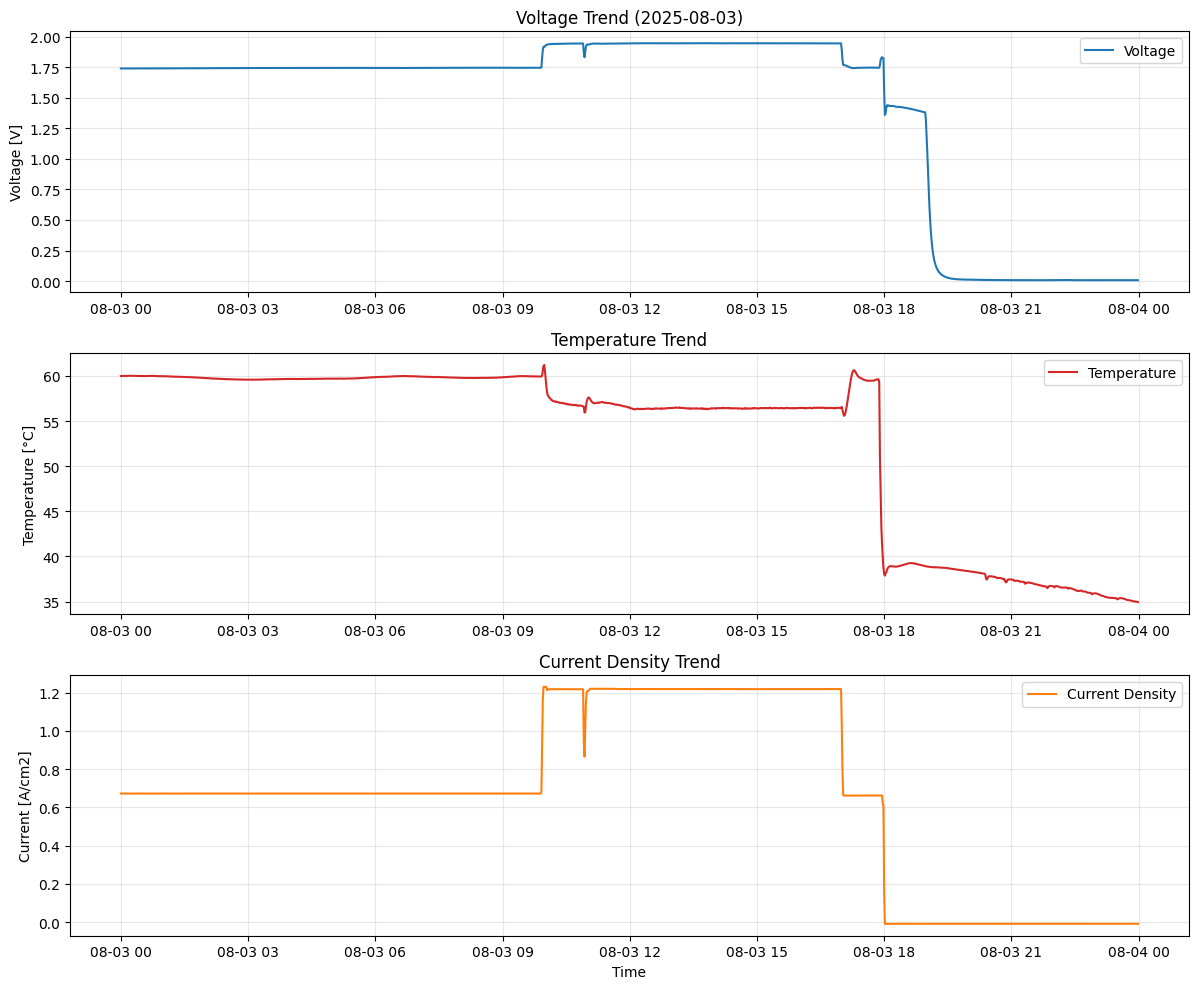


==================== 4. Coefficient of Variation (CV) Analysis ====================
Note: CV < 1% usually indicates a steady state (no significant variation).
currentDensity : CV = 68.0751%
temperature    : CV = 17.5110%
voltage        : CV = 50.9234%

==================== 5. Correlation Matrix (Collinearity Check) ====================
                currentDensity  temperature   voltage
currentDensity        1.000000     0.773527  0.854366
temperature           0.773527     1.000000  0.905847
voltage               0.854366     0.905847  1.000000

>>> Correlation (Current vs Temp): 0.7735
 [Diagnosis] Independence seems acceptable.

==================== 6. Joint Distribution (Current vs Temp) ====================


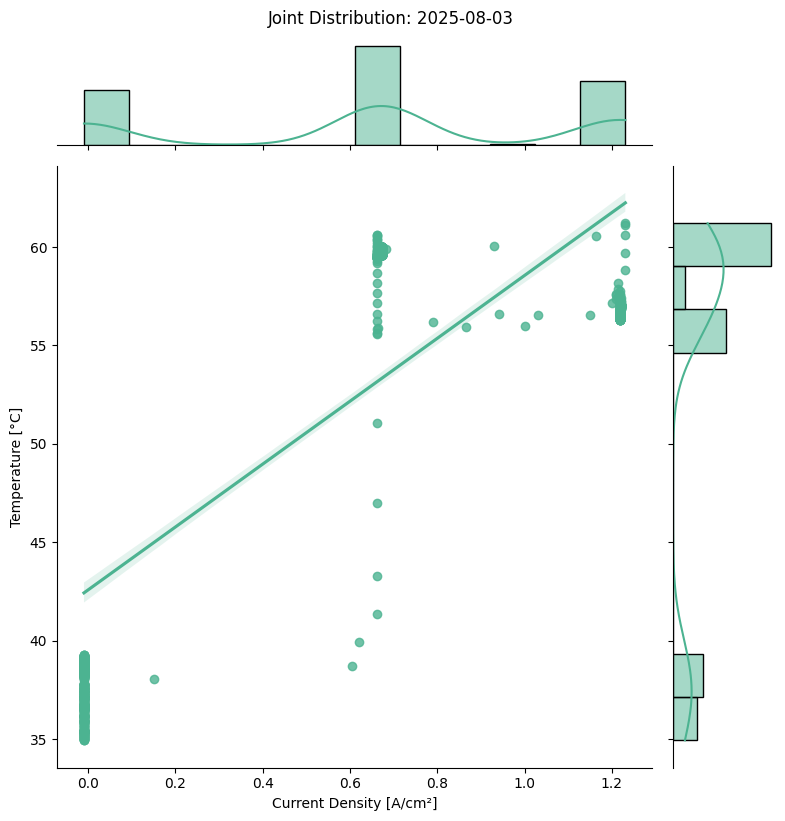


==================== 7. 2D Density Distribution (KDE) ====================


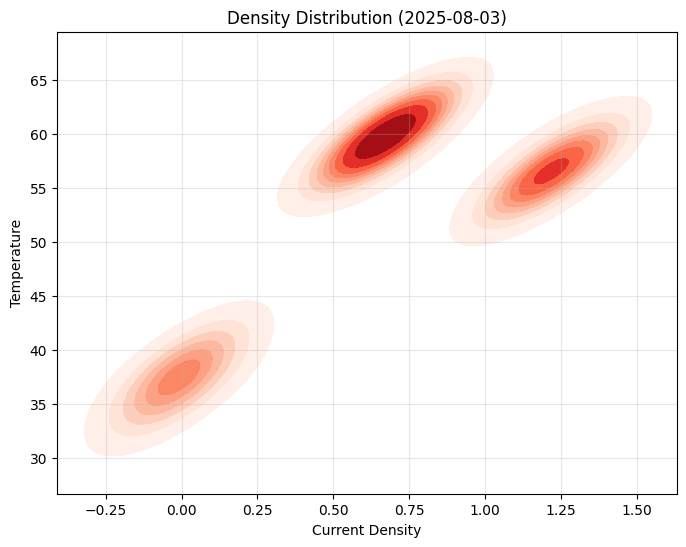


==================== 3. Interactive 3D Spatial Distribution ====================


In [3]:
diagnoser = DataDiagnostician(data)
diagnoser.run_full_diagnosis("2025-08-03")